In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from textblob import TextBlob

In [2]:
df = pd.read_csv("competitor_analysis_dataset.csv")

In [3]:
df = df.dropna()
df = df.drop_duplicates()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

df['clean_text'] = df['post_text'].apply(clean_text)

In [4]:
df['engagement'] = df['likes'] + df['comments'] + df['shares']

In [5]:
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

df['polarity'] = df['clean_text'].apply(get_sentiment)

def classify(p):
    if p > 0:
        return "positive"
    elif p < 0:
        return "negative"
    else:
        return "neutral"

df['sentiment'] = df['polarity'].apply(classify)

In [16]:
brand_groups = df.groupby('brand') #split by brand
print(brand_groups['engagement'].mean()) #average engagement by brand

brand
Adidas    637.330979
Nike      672.742095
Puma      636.710130
Name: engagement, dtype: float64


In [7]:
#Comparison
#Number of posts
post_counts = df['brand'].value_counts()
print(post_counts)

#Average engagement
engagement = brand_groups['engagement'].mean()
print(engagement)

#Sentiment Distribution
sentiment_distribution=df.groupby(['brand','sentiment']).size().unstack(fill_value=0)
print(sentiment_distribution)

brand
Nike      1012
Puma       997
Adidas     991
Name: count, dtype: int64
brand
Adidas    637.330979
Nike      672.742095
Puma      636.710130
Name: engagement, dtype: float64
sentiment  negative  positive
brand                        
Adidas          452       539
Nike            424       588
Puma            463       534


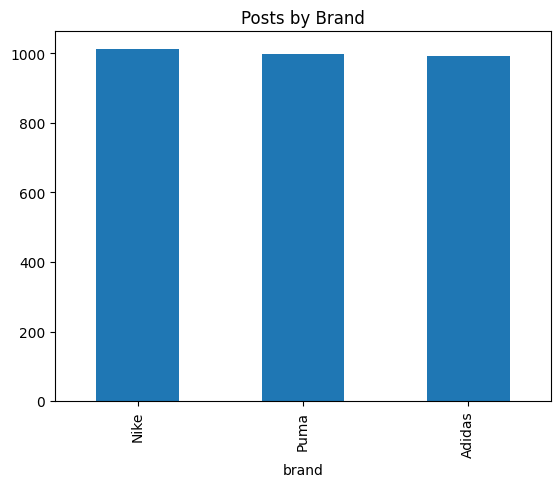

In [8]:
post_counts.plot(kind='bar')
plt.title("Posts by Brand")
plt.show()

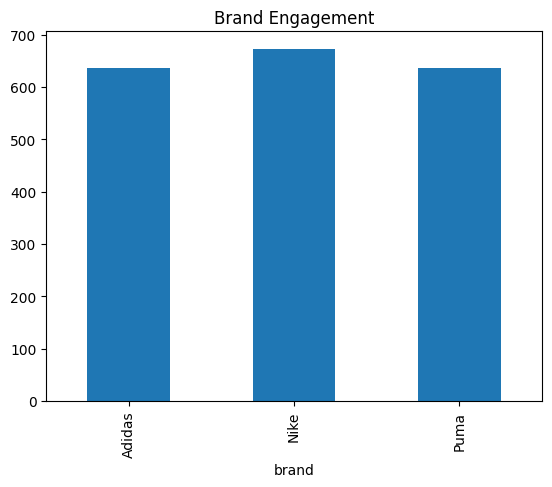

In [9]:
engagement.plot(kind='bar')
plt.title("Brand Engagement")
plt.show()

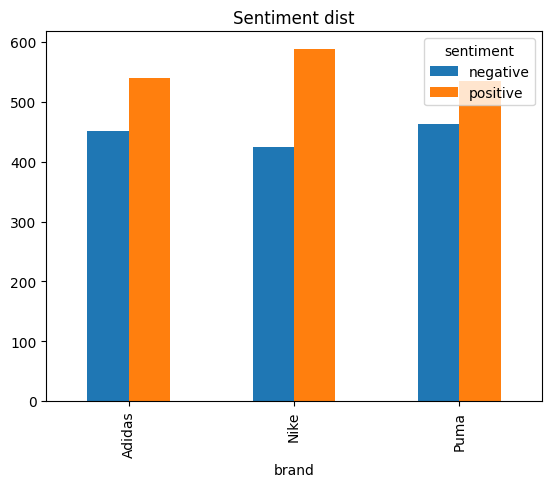

In [10]:
sentiment_distribution.plot(kind='bar')
plt.title("Sentiment dist")
plt.show()